In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from parameters import *

## Ramp Slope Analysis 

### GOE

In [14]:
dataList = []
dataList.append(np.loadtxt(f"SFF/goe_sff_data,j={j},M={M},N={N},ntraj=1000.dat",dtype=complex))

FileNotFoundError: SFF/goe_sff_data,j=20,M=80,N=1240,ntraj=1000.dat not found.

c:\Users\prasa\miniconda3\envs\scicalc\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\prasa\miniconda3\envs\scicalc\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


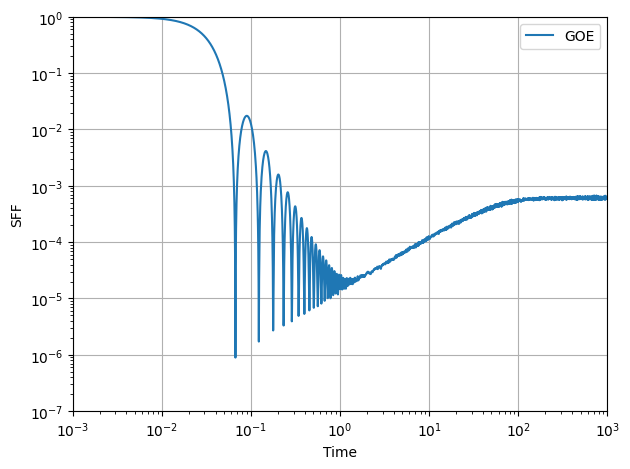

In [ ]:
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Time")
plt.ylabel("SFF")
plt.xlim(1e-3,1e3)
plt.ylim(1e-7,1)

# GOE data
data1 = np.loadtxt(f"SFF/goe_sff_data,j={j},M={M},N={N},ntraj=1000.dat",dtype=complex)

# Isolate the ramp
indl = int(2.05e3); indr = int(4e3)
indl = int(2e3); indr = int(3.4e3)
data_ramp_GOE = data1[indl:indr]

# Plot the actual data
data1 = np.column_stack(data1)
plt.plot(data1[0],data1[1],label=f"GOE")

# Plot the ramp
data_ramp_GOE = np.column_stack(data_ramp_GOE)
# plt.plot(data_ramp_GOE[0], data_ramp_GOE[1])

# Plot the fit
# Fit the ramp
m,b = np.polyfit(np.log10(data_ramp_GOE[0]),np.log10(data_ramp_GOE[1]),1)
# print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data1[0][indl]),2)}")
# plt.plot(data1[0], 10**b*data1[0]**m,'--',label= f"slope = {round(np.real(m),2)}")
#plt.plot(data[0], 10**b*data[0]**m,'--',label=f"g={np.round(g_arr[g_ind])}, m={round(np.real(m),2)}")

plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('GOE SFF')

## Dicke

In [8]:
g_arr = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
M_arr = [50, 60, 70, 80, 400]
M_arr = [80]
j = 20

In [9]:
dataList = []
beta = 0
for g in g_arr:
    dataList1 = []
    for M in M_arr:
        data = np.loadtxt(f"SFF/SFFvsTime,j={j},M={M},g={g},beta={beta}.dat", dtype=complex)
        # Rolling average data points
        data_rl = []
        # Window size for rolling average
        win = 100
        for data_ind in tqdm(range(0,len(data),1)):
            win_start = int(data_ind)
            win_end = int(data_ind+win)
            data_rl_val = np.average(data[win_start:win_end], axis=0)
            data_rl.append(data_rl_val)
        dataList1.append(data_rl)
    dataList.append(dataList1)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:00<00:00, 50399.59it/s]


g=0.1, m=1.67,t=1.45
g=0.3, m=1.49,t=1.45
g=0.5, m=1.07,t=1.45
g=0.7, m=0.89,t=1.45
g=0.9, m=0.95,t=1.45
g=1.0, m=0.84,t=1.45


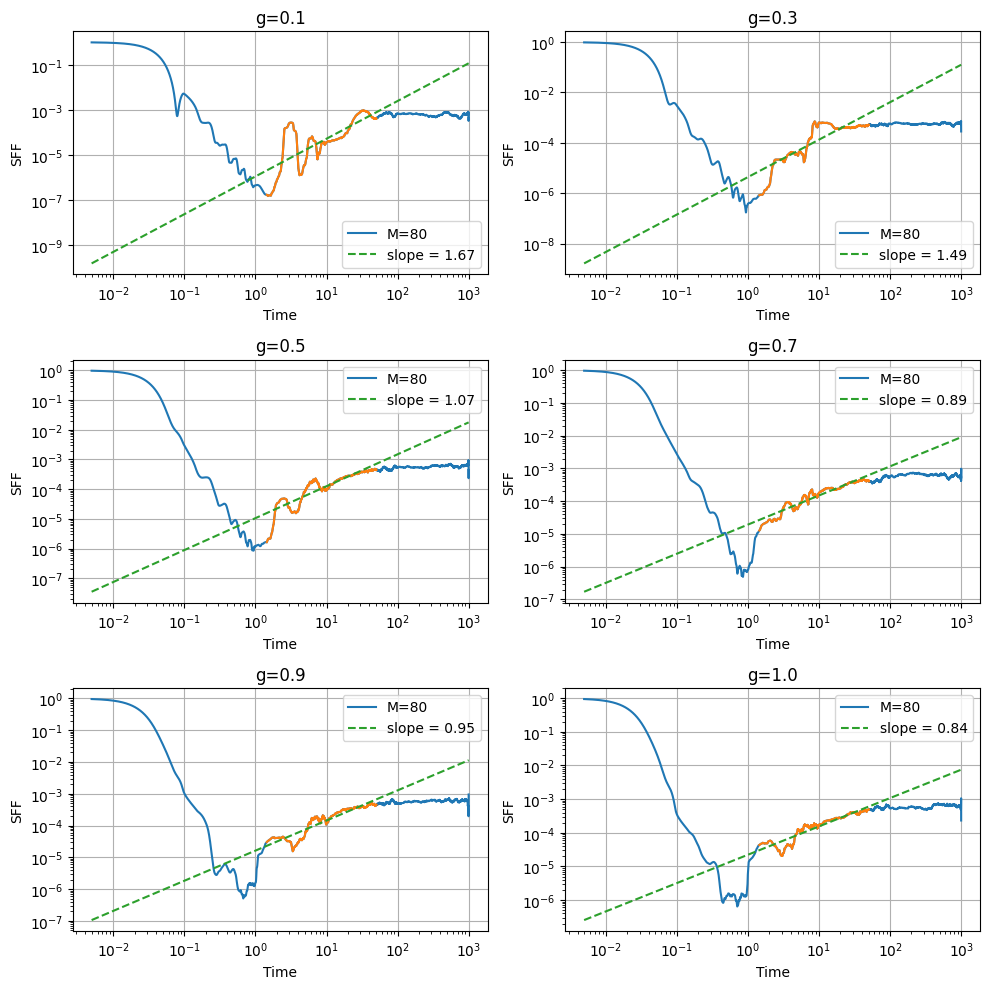

In [13]:
plt.figure(figsize=(10,10))
m_arr_arr = []
for g_ind, dataList1 in enumerate(dataList):
    m_arr = []
    for M_ind, data in enumerate(dataList1):
        #plt.suptitle(f"Dicke Model SFF (j={j}, M={M})")
        plt.subplot(3,2,g_ind+1)
        plt.title(f"g={round(g_arr[g_ind],2)}")
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Time")
        plt.ylabel("SFF")
        # plt.xlim(1e-3,1e3)
        # plt.ylim(1e-40,1)
        
        # Isolate the ramp
        indl = int(2e3); indr = int(3.4e3)

        data_ramp = data[indl:indr]

        # Plot the actual data
        data = np.column_stack(data)
        plt.plot(data[0],data[1],label=f"M={M_arr[M_ind]}")

        # Plot the ramp
        data_ramp = np.column_stack(data_ramp)
        plt.plot(data_ramp[0], data_ramp[1])

        # Plot the fit
        # Fit the ramp
        m,b = np.polyfit(np.log10(data_ramp[0]),np.log10(data_ramp[1]),1)
        print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data[0][indl]),2)}")
        plt.plot(data[0], 10**b*data[0]**m,'--',label= f"slope = {round(np.real(m),2)}")
        m_arr.append(m)
        plt.tight_layout()
        plt.grid()
    m_arr_arr.append(m_arr)
    plt.legend()
plt.savefig('plots/Dicke SFF Slope')


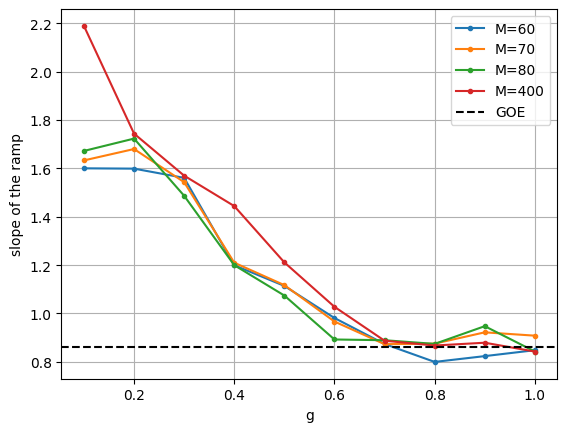

In [11]:
m_arr_arr = np.column_stack(m_arr_arr)
for M_ind, m_arr in enumerate(m_arr_arr):
    # plt.title(f"Dicke Model with Cavity Decay "+r"($\gamma=1$)")
    plt.plot(g_arr,m_arr,'.-',label=f'M={M_arr[M_ind]}')
    plt.xlabel('g')
    plt.ylabel('slope of the ramp')
    plt.grid()
plt.axhline(y=0.86,linestyle='--',color='k',label='GOE')
plt.legend()
plt.grid()
plt.savefig("plots/ramp slope vs g for different M")
plt.show()